<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Exploratory Data Analysis Lab**


Estimated time needed: **30** minutes


In this module you get to work with the cleaned dataset from the previous module.

In this assignment you will perform the task of exploratory data analysis.
You will find out the distribution of data, presence of outliers and also determine the correlation between different columns in the dataset.


## Objectives


In this lab you will perform the following:


-   Identify the distribution of data in the dataset.

-   Identify outliers in the dataset.

-   Remove outliers from the dataset.

-   Identify correlation between features in the dataset.


* * *


## Hands on Lab


Import the pandas module.


In [1]:
from math import radians
import numpy as np                # installed with matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stat

In [2]:
import pandas as pd

Load the dataset into a dataframe.


In [35]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv")
df.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'OpenSourcer', 'OpenSource',
       'Employment', 'Country', 'Student', 'EdLevel', 'UndergradMajor',
       'EduOther', 'OrgSize', 'DevType', 'YearsCode', 'Age1stCode',
       'YearsCodePro', 'CareerSat', 'JobSat', 'MgrIdiot', 'MgrMoney',
       'MgrWant', 'JobSeek', 'LastHireDate', 'LastInt', 'FizzBuzz',
       'JobFactors', 'ResumeUpdate', 'CurrencySymbol', 'CurrencyDesc',
       'CompTotal', 'CompFreq', 'ConvertedComp', 'WorkWeekHrs', 'WorkPlan',
       'WorkChallenge', 'WorkRemote', 'WorkLoc', 'ImpSyn', 'CodeRev',
       'CodeRevHrs', 'UnitTests', 'PurchaseHow', 'PurchaseWhat',
       'LanguageWorkedWith', 'LanguageDesireNextYear', 'DatabaseWorkedWith',
       'DatabaseDesireNextYear', 'PlatformWorkedWith',
       'PlatformDesireNextYear', 'WebFrameWorkedWith',
       'WebFrameDesireNextYear', 'MiscTechWorkedWith',
       'MiscTechDesireNextYear', 'DevEnviron', 'OpSys', 'Containers',
       'BlockchainOrg', 'BlockchainIs', 'BetterLife'

In [181]:
empty = []
print(empty)
empty.extend(df['LanguageWorkedWith'][1].split(';'))
print(empty)
empty.extend(df['LanguageWorkedWith'][2].split(';'))
empty


[]
['Bash/Shell/PowerShell', 'C#', 'HTML/CSS', 'JavaScript', 'Python', 'Ruby', 'Rust', 'SQL', 'TypeScript', 'WebAssembly', 'Other(s):']


['Bash/Shell/PowerShell',
 'C#',
 'HTML/CSS',
 'JavaScript',
 'Python',
 'Ruby',
 'Rust',
 'SQL',
 'TypeScript',
 'WebAssembly',
 'Other(s):',
 'Bash/Shell/PowerShell',
 'HTML/CSS',
 'JavaScript',
 'PHP',
 'SQL',
 'TypeScript']

In [199]:
# Language Counter

def lang_count(column):
    words_list = []
    for n in np.arange(0,len(column)):
        if isinstance(column[n], str):
            temp_list = (column[n]).split(';')
            if len(temp_list) > 1:
                words_list.extend(temp_list)
            else:
                words_list.append(temp_list)
    return words_list


In [201]:
pd.Series(lang_count(df['LanguageWorkedWith'])).value_counts()

11398
8
18


JavaScript                 8645
HTML/CSS                   7830
SQL                        7100
Bash/Shell/PowerShell      4637
Python                     4483
Java                       4439
C#                         4214
TypeScript                 3231
PHP                        2904
C++                        1940
C                          1577
Ruby                       1134
Go                         1113
Other(s):                   829
Kotlin                      748
Swift                       696
VBA                         628
R                           585
Objective-C                 517
Scala                       483
Assembly                    437
Rust                        324
Dart                        236
Elixir                      186
Clojure                     163
F#                          158
WebAssembly                 133
Erlang                       98
[C#]                         74
[Java]                       67
[Python]                     59
[JavaScr

## Distribution


### Determine how the data is distributed


The column `ConvertedComp` contains Salary converted to annual USD salaries using the exchange rate on 2019-02-01.

This assumes 12 working months and 50 working weeks.


Plot the distribution curve for the column `ConvertedComp`.


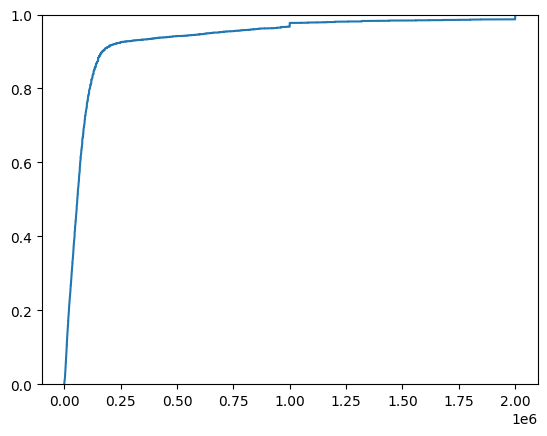

In [38]:
# your cod# your code goes here
fig, ax = plt.subplots()
ax.ecdf(df['ConvertedComp'].dropna())
plt.show()

Plot the histogram for the column `ConvertedComp`.


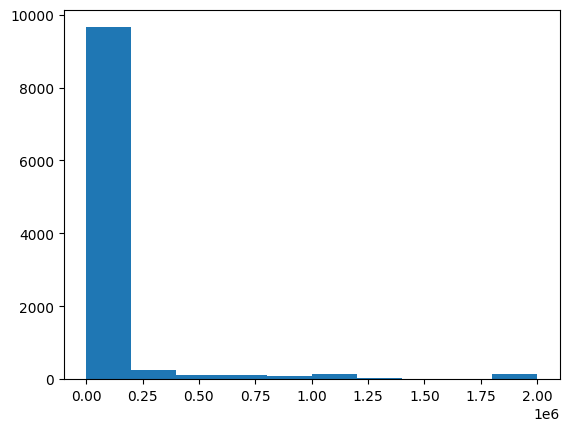

In [35]:
# your cod# your code goes here
fig, ax = plt.subplots()
ax.hist(df['ConvertedComp'], bins=10)
plt.show()

What is the median of the column `ConvertedComp`?


In [34]:
# your code goes here
print(df['ConvertedComp'].median())
df['ConvertedComp'].describe()

57745.0


count    1.058200e+04
mean     1.315967e+05
std      2.947865e+05
min      0.000000e+00
25%      2.686800e+04
50%      5.774500e+04
75%      1.000000e+05
max      2.000000e+06
Name: ConvertedComp, dtype: float64

How many responders identified themselves only as a **Man**?


In [21]:
# your code goes here
df.columns
df['Gender'].value_counts()

Gender
Man                                                            10480
Woman                                                            731
Non-binary, genderqueer, or gender non-conforming                 63
Man;Non-binary, genderqueer, or gender non-conforming             26
Woman;Non-binary, genderqueer, or gender non-conforming           14
Woman;Man                                                          9
Woman;Man;Non-binary, genderqueer, or gender non-conforming        2
Name: count, dtype: int64

Find out the  median ConvertedComp of responders identified themselves only as a **Woman**?


In [12]:
# your code goes here
df.loc[df['Gender']=='Woman']['ConvertedComp'].median()

np.float64(57708.0)

Give the five number summary for the column `Age`?


**Double click here for hint**.

<!--
min,q1,median,q3,max of a column are its five number summary.
-->


In [4]:
# your code goes here
df['Age'].describe()

count    11111.000000
mean        30.778895
std          7.393686
min         16.000000
25%         25.000000
50%         29.000000
75%         35.000000
max         99.000000
Name: Age, dtype: float64

Plot a histogram of the column `Age`.


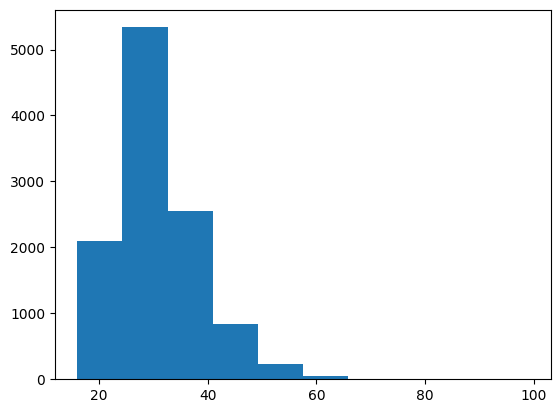

In [53]:
# your code goes here
fig, ax = plt.subplots()
ax.hist(df['Age'], bins=10)
plt.show()

In [57]:
# Before removing outliers
print('Before removing outlifer \n', df['ConvertedComp'].describe(), '\n_______')
print('Afer removing outliers \n,')

Before removing outlifer 
 count    1.058200e+04
mean     1.315967e+05
std      2.947865e+05
min      0.000000e+00
25%      2.686800e+04
50%      5.774500e+04
75%      1.000000e+05
max      2.000000e+06
Name: ConvertedComp, dtype: float64 
 _______
Afer removing outliers 
,


## Outliers


### Finding outliers


Find out if outliers exist in the column `ConvertedComp` using a box plot?


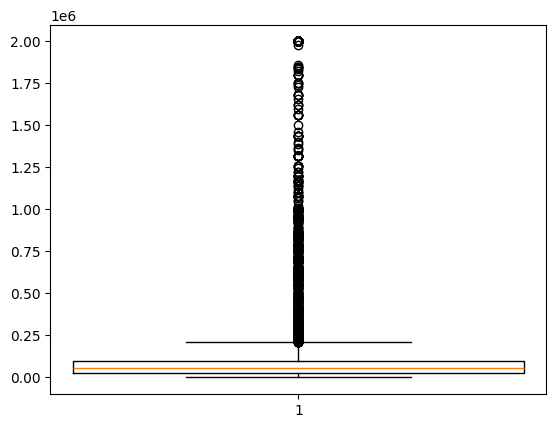

In [47]:
# your code goes here
fig, ax = plt.subplots()
ax.boxplot(df['ConvertedComp'].dropna(), widths=1.5)
plt.show()


Find out the Inter Quartile Range for the column `ConvertedComp`.


In [48]:
# your code goes here
iqr = np.percentile(df['ConvertedComp'].dropna(), 75)-np.percentile(df['ConvertedComp'].dropna(), 25)
iqr

np.float64(73132.0)

Find out the upper and lower bounds.


In [66]:
# your code goes here
print(np.percentile(df['ConvertedComp'].dropna(), 75))
print(np.percentile(df['ConvertedComp'].dropna(), 25))
upper = np.percentile(df['ConvertedComp'].dropna(), 75) + iqr*1.5
lower = np.percentile(df['ConvertedComp'].dropna(), 25) - iqr*1.5
print(upper, lower)

100000.0
26868.0
209698.0 -82830.0


Identify how many outliers are there in the `ConvertedComp` column.


In [86]:
# your code goes here

df['ConvertedComp'].dropna().loc[(df['ConvertedComp'] < lower) | (df['ConvertedComp'] > upper)].shape


(879,)

Create a new dataframe by removing the outliers from the `ConvertedComp` column.


In [101]:
# your code goes here
df_new = df.loc[(df['ConvertedComp'] > lower) & (df['ConvertedComp'] < upper)]
print(df_new.head())
print(df_new.shape)
print(df_new['ConvertedComp'].dropna().mean())

   Respondent                      MainBranch Hobbyist  \
0           4  I am a developer by profession       No   
1           9  I am a developer by profession      Yes   
2          13  I am a developer by profession      Yes   
4          17  I am a developer by profession      Yes   
5          19  I am a developer by profession      Yes   

                                         OpenSourcer  \
0                                              Never   
1                         Once a month or more often   
2  Less than once a month but more than once per ...   
4  Less than once a month but more than once per ...   
5                                              Never   

                                          OpenSource          Employment  \
0  The quality of OSS and closed source software ...  Employed full-time   
1  The quality of OSS and closed source software ...  Employed full-time   
2  OSS is, on average, of HIGHER quality than pro...  Employed full-time   
4  The qua

In [ ]:
df

## Correlation


### Finding correlation


Find the correlation between `Age` and all other numerical columns.


In [100]:
# your code goes here
df.corr(numeric_only=True)

,Respondent,CompTotal,ConvertedComp,WorkWeekHrs,CodeRevHrs,Age
Respondent,1.000000,-0.013490,0.002181,-0.015314,0.004621,0.004041
CompTotal,-0.013490,1.000000,0.001037,0.003510,0.007063,0.006970
ConvertedComp,0.002181,0.001037,1.000000,0.021143,-0.033865,0.105386
WorkWeekHrs,-0.015314,0.003510,0.021143,1.000000,0.026517,0.036518
CodeRevHrs,0.004621,0.007063,-0.033865,0.026517,1.000000,-0.020469
Age,0.004041,0.006970,0.105386,0.036518,-0.020469,1.000000


## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |


 Copyright © 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2023-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ).
